# Convolutional Neural Networks

a)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, ConcatDataset
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import pandas as pd

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}")

# Define transformation
basic_transform = transforms.Compose([transforms.ToTensor(),
                                      transforms.Normalize((0.5,), (0.5,))
                                      ])

# Load Data from csv
full_train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=basic_transform)
test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=basic_transform)

# Validation-Split
val_size = int(0.2 * len(full_train_data))
train_size = len(full_train_data) - val_size
train_data, val_data = random_split(full_train_data, [train_size, val_size])

# Dataloader
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

Using cuda


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.91MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.1MB/s]


b)

In [2]:
class FlexibleCNN(nn.Module):
    def __init__(self, config_name, layers_config, dropout_rate=0.0):
        super(FlexibleCNN, self).__init__()
        self.name = config_name
        self.features = nn.Sequential()

        in_channels = 1

        # Building Layers dynamically based on config
        # Example Config: [32, 'M', 64, 'M'] -> 32 Filter, MaxPool, 64 Filter, MaxPool
        for i, x in enumerate(layers_config):
            if x == 'M':
                self.features.add_module(f'pool{i}', nn.MaxPool2d(kernel_size=2, stride=2))
            else:
                self.features.add_module(f'conv{i}', nn.Conv2d(in_channels, x, kernel_size=3, padding=1))
                self.features.add_module(f'relu{i}', nn.ReLU())
                in_channels = x

        # Calculation of Flatten-size (for 28x28 Input)
        # Dummy-Pass to define size
        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, 28, 28)
            dummy_out = self.features(dummy_input)
            self.flatten_dim = dummy_out.view(1, -1).size(1)

        self.classifier = nn.Sequential(
            nn.Linear(self.flatten_dim, 128),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

def get_accuracy_and_error(model, loader, device):
    correct = 0
    total = 0
    model.eval() # set the model to evaluation mode (deactivate Dropout!)
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs.data, 1)
            total += lbls.size(0)
            correct += (predicted == lbls).sum().item()
    model.train() # Set model back to training mode

    acc = 100 * correct / total
    err = total - correct
    return acc, err

#  5 architectures
configs = {
    "Arch_1_Baseline": [16, 'M', 32, 'M'],           # Standard
    "Arch_2_Wide":     [32, 'M', 64, 'M'],           # wider (more Filter)
    "Arch_3_Deep":     [16, 'M', 32, 'M', 64],       # deeper (3 Conv Layer)
    "Arch_4_DeepWide": [32, 'M', 64, 'M', 128],      # deep & wide
    "Arch_5_Narrow":   [8, 'M', 16, 'M']             # narrow (less Parameter)
}

# Training function with Early Stopping
def train_and_evaluate(model, train_loader, val_loader, epochs=15, patience=3, weight_decay=0):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=weight_decay)

    best_val_loss = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    best_train_acc = 0.0
    best_val_acc = 0.0
    best_train_err = 0
    best_val_err = 0

    print(f"--- Training {model.name} ---")

    for epoch in range(epochs):
        # Training
        model.train()
        run_loss = 0.0
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()
            run_loss += loss.item()

        avg_train_loss = run_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, lbls)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += lbls.size(0)
                correct += (predicted == lbls).sum().item()

        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct / total

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f}, Val Loss {avg_val_loss:.4f}")

        # Early Stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0

            # Save metrics for table
            best_train_acc, best_train_err = get_accuracy_and_error(model, train_loader, device)
            best_val_acc, best_val_err = get_accuracy_and_error(model, val_loader, device)

            # save model
            torch.save(model.state_dict(), f'{model.name}_best.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early Stopping triggered.")
                break

    return {
        'best_val_loss': best_val_loss,
        'best_train_acc': best_train_acc,
        'best_val_acc': best_val_acc,
        'best_train_err': best_train_err,
        'best_val_err': best_val_err,
        'history': history
    }

# Execute exercises for task b)
results = {}
for name, conf in configs.items():
    model = FlexibleCNN(name, conf).to(device)
    # count parameters
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Params: {num_params}")

    hist = train_and_evaluate(model, train_loader, val_loader)
    results[name] = {'history': hist, 'params': num_params}

Params: 206922
--- Training Arch_1_Baseline ---
Epoch 1: Train Loss 0.4979, Val Loss 0.3902
Epoch 2: Train Loss 0.3242, Val Loss 0.3184
Epoch 3: Train Loss 0.2789, Val Loss 0.2714
Epoch 4: Train Loss 0.2466, Val Loss 0.2623
Epoch 5: Train Loss 0.2248, Val Loss 0.2554
Epoch 6: Train Loss 0.2050, Val Loss 0.2478
Epoch 7: Train Loss 0.1852, Val Loss 0.2535
Epoch 8: Train Loss 0.1690, Val Loss 0.2474
Epoch 9: Train Loss 0.1516, Val Loss 0.2473
Epoch 10: Train Loss 0.1361, Val Loss 0.2445
Epoch 11: Train Loss 0.1224, Val Loss 0.2521
Epoch 12: Train Loss 0.1102, Val Loss 0.2635
Epoch 13: Train Loss 0.0967, Val Loss 0.2787
Early Stopping triggered.
Params: 421642
--- Training Arch_2_Wide ---
Epoch 1: Train Loss 0.4605, Val Loss 0.3180
Epoch 2: Train Loss 0.2898, Val Loss 0.2713
Epoch 3: Train Loss 0.2435, Val Loss 0.2934
Epoch 4: Train Loss 0.2086, Val Loss 0.2476
Epoch 5: Train Loss 0.1806, Val Loss 0.2621
Epoch 6: Train Loss 0.1567, Val Loss 0.2411
Epoch 7: Train Loss 0.1338, Val Loss 0.273

c)

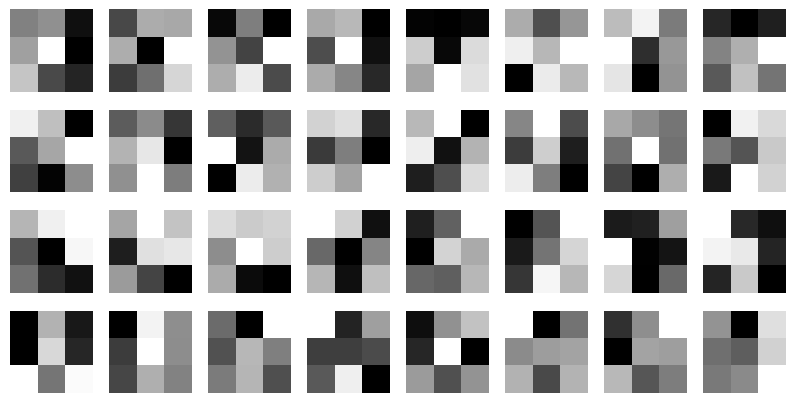

In [3]:
# load best Model
best_model_name = "Arch_4_DeepWide"
best_model = FlexibleCNN(best_model_name, configs[best_model_name]).to(device)
best_model.load_state_dict(torch.load(f'{best_model_name}_best.pth'))

# Kernel visualization
kernels = best_model.features[0].weight.data.cpu() # first Conv Layer
fig, axs = plt.subplots(4, 8, figsize=(10, 5)) # Adjust depending on number of filters (z.B. 32)
for i, ax in enumerate(axs.flat):
    if i < kernels.size(0):
        ax.imshow(kernels[i, 0], cmap='gray')
        ax.axis('off')
plt.show()

d)

In [4]:
# 1. Define Data Augmentation
aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

aug_train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=aug_transform)

# Indizes of Subsets train_data (created with random_split)
aug_train_subset = torch.utils.data.Subset(aug_train_data, train_data.indices)

# New Loader only for for trining (use Indices from Split)
aug_train_loader = DataLoader(aug_train_subset, batch_size=64, shuffle=True)
base_train_loader = train_loader

best_config_name = "Arch_4_DeepWide"

# Definition of 7 Test-settings
test_settings = [
    # 1. Baseline
    {'name': 'Baseline', 'wd': 0.0, 'do': 0.0, 'loader': base_train_loader, 'aug': 'Nein'},
    # 2. L2 regularization
    {'name': 'L2 (WD 1e-5)', 'wd': 1e-5, 'do': 0.0, 'loader': base_train_loader, 'aug': 'Nein'},
    {'name': 'L2 (WD 1e-4)', 'wd': 1e-4, 'do': 0.0, 'loader': base_train_loader, 'aug': 'Nein'},
    # 3. Dropout regularization
    {'name': 'Dropout (DO 0.2)', 'wd': 0.0, 'do': 0.2, 'loader': base_train_loader, 'aug': 'Nein'},
    {'name': 'Dropout (DO 0.5)', 'wd': 0.0, 'do': 0.5, 'loader': base_train_loader, 'aug': 'Nein'},
    # 4. Data Augmentation
    {'name': 'Data Augmentation', 'wd': 0.0, 'do': 0.0, 'loader': aug_train_loader, 'aug': 'Ja'},
    # 5. combination (final Setting)
    {'name': 'Kombination (Final)', 'wd': 1e-4, 'do': 0.5, 'loader': aug_train_loader, 'aug': 'Ja'},
]

regularization_results = []

for setting in test_settings:
    model = FlexibleCNN(
        setting['name'],
        configs[best_config_name],
        dropout_rate=setting['do']
    ).to(device)

    print(f"\n--- Starte Test: {setting['name']} ---")

    # call function with konfigurated values
    hist_metrics = train_and_evaluate(
        model,
        setting['loader'],
        val_loader,
        weight_decay=setting['wd']
    )

    # Save results
    regularization_results.append({
        'Setting': setting['name'],
        'L2 (WD)': setting['wd'],
        'Dropout (DO)': setting['do'],
        'Augmentation': setting['aug'],
        'Train Acc (%)': hist_metrics['best_train_acc'],
        'Val Acc (%)': hist_metrics['best_val_acc'],
        'Train Error': hist_metrics['best_train_err'],
        'Val Error': hist_metrics['best_val_err'],
    })

# Show final table
df_results = pd.DataFrame(regularization_results)
print(df_results)



--- Starte Test: Baseline ---
--- Training Baseline ---
Epoch 1: Train Loss 0.4325, Val Loss 0.2972
Epoch 2: Train Loss 0.2692, Val Loss 0.2747
Epoch 3: Train Loss 0.2220, Val Loss 0.2476
Epoch 4: Train Loss 0.1894, Val Loss 0.2398
Epoch 5: Train Loss 0.1626, Val Loss 0.2239
Epoch 6: Train Loss 0.1360, Val Loss 0.2228
Epoch 7: Train Loss 0.1147, Val Loss 0.2548
Epoch 8: Train Loss 0.0921, Val Loss 0.2537
Epoch 9: Train Loss 0.0765, Val Loss 0.2843
Early Stopping triggered.

--- Starte Test: L2 (WD 1e-5) ---
--- Training L2 (WD 1e-5) ---
Epoch 1: Train Loss 0.4453, Val Loss 0.3201
Epoch 2: Train Loss 0.2719, Val Loss 0.2612
Epoch 3: Train Loss 0.2280, Val Loss 0.2358
Epoch 4: Train Loss 0.1941, Val Loss 0.2253
Epoch 5: Train Loss 0.1635, Val Loss 0.2356
Epoch 6: Train Loss 0.1381, Val Loss 0.2337
Epoch 7: Train Loss 0.1145, Val Loss 0.2403
Early Stopping triggered.

--- Starte Test: L2 (WD 1e-4) ---
--- Training L2 (WD 1e-4) ---
Epoch 1: Train Loss 0.4495, Val Loss 0.3209
Epoch 2: Trai

e)

--- Training Final_Model ---
Epoch 1: Train Loss 0.5209, Val Loss 0.3023
Epoch 2: Train Loss 0.3301, Val Loss 0.2481
Epoch 3: Train Loss 0.2783, Val Loss 0.2091
Epoch 4: Train Loss 0.2454, Val Loss 0.1876
Epoch 5: Train Loss 0.2211, Val Loss 0.1679
Epoch 6: Train Loss 0.2024, Val Loss 0.1448
Epoch 7: Train Loss 0.1815, Val Loss 0.1335
Epoch 8: Train Loss 0.1629, Val Loss 0.1169
Epoch 9: Train Loss 0.1496, Val Loss 0.1062
Epoch 10: Train Loss 0.1329, Val Loss 0.0947
Epoch 11: Train Loss 0.1225, Val Loss 0.0743
Epoch 12: Train Loss 0.1088, Val Loss 0.0646
Epoch 13: Train Loss 0.1007, Val Loss 0.0668
Epoch 14: Train Loss 0.0920, Val Loss 0.0591
Epoch 15: Train Loss 0.0834, Val Loss 0.0440
Epoch 16: Train Loss 0.0801, Val Loss 0.0441
Epoch 17: Train Loss 0.0736, Val Loss 0.0345
Epoch 18: Train Loss 0.0686, Val Loss 0.0342
Epoch 19: Train Loss 0.0667, Val Loss 0.0371
Epoch 20: Train Loss 0.0631, Val Loss 0.0281
Epoch 21: Train Loss 0.0600, Val Loss 0.0239
Epoch 22: Train Loss 0.0559, Val Lo

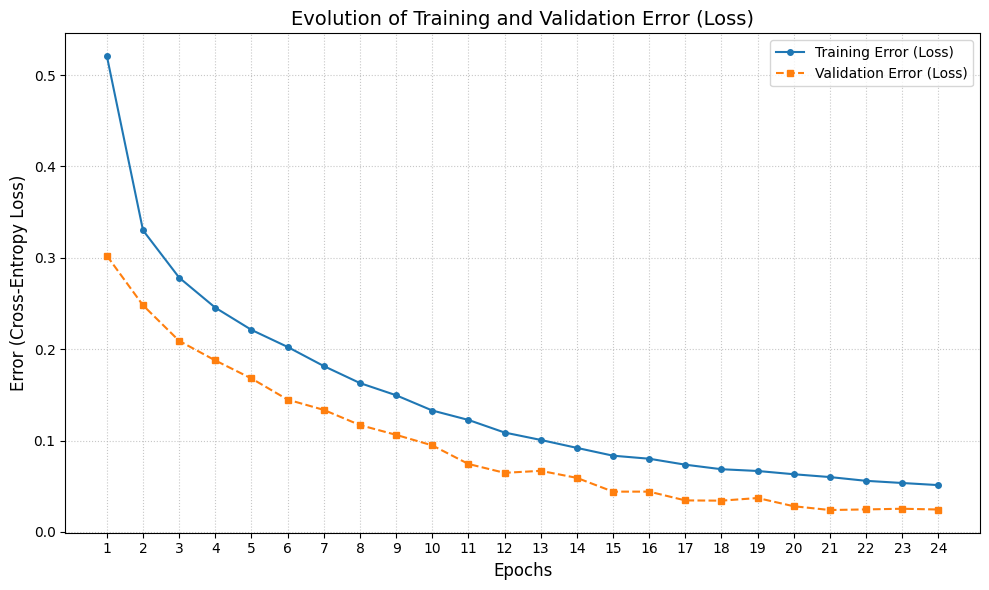

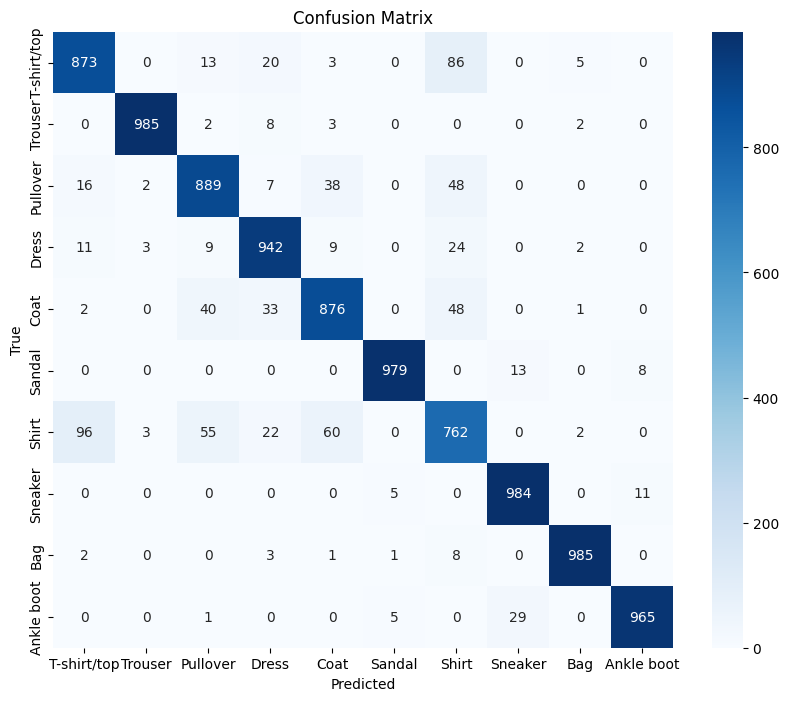

In [9]:
# 1. Final Training with complete data (Train + Val)
full_train_loader = DataLoader(full_train_data, batch_size=64, shuffle=True)

final_model = FlexibleCNN("Final_Model", configs[best_model_name], dropout_rate=0.5).to(device)

# Save metrics to be able to show graph:
final_hist_metrics = train_and_evaluate(final_model, full_train_loader, val_loader,epochs=35)

# 2. Test Set Evaluation & Confusion Matrix
all_preds = []
all_labels = []

final_model.eval()
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        outputs = final_model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.cpu().numpy())

# Metrics
acc = accuracy_score(all_labels, all_preds)
print(f"Final Test Accuracy: {acc*100:.2f}%")

# 3 Plot evolution of training and validation error
history = final_hist_metrics['history']
epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(10, 6))

# Plotting of Training and  Validation-Loss
plt.plot(epochs, history['train_loss'], label='Training Error (Loss)', marker='o', linestyle='-', markersize=4)
plt.plot(epochs, history['val_loss'], label='Validation Error (Loss)', marker='s', linestyle='--', markersize=4)

plt.title('Evolution of Training and Validation Error (Loss)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Error (Cross-Entropy Loss)', fontsize=12)
plt.xticks(epochs)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_data.classes, yticklabels=test_data.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
